In [15]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# --- Load Data from Previous Steps ---
A = np.load('../data/A_matrix.npy')
A_basis = np.load('../data/A_basis.npy')
A_projected = np.load('../data/A_projected.npy')
player_names = pd.read_csv('../data/player_names.csv').iloc[:, 0].values
features = pd.read_csv('../data/features.csv').iloc[:, 0].values
basis_features = pd.read_csv('../data/basis_features.csv').iloc[:, 0].values

print("Data loaded successfully!")
print(f"A_basis shape    : {A_basis.shape}")
print(f"A_projected shape: {A_projected.shape}")

Data loaded successfully!
A_basis shape    : (1130, 9)
A_projected shape: (1130, 9)


In [17]:
# --- What is Least Squares? ---
# When a system Ax = b has no exact solution (overdetermined),
# least squares finds the BEST APPROXIMATE solution x_hat
# that minimizes the residual error ||Ax - b||²
#
# Formula: x_hat = (AᵀA)⁻¹Aᵀb
# NumPy:   np.linalg.lstsq(A, b)
#
# For our project:
#   → A = known player stats (design matrix)
#   → b = target stat we want to predict
#   → x_hat = coefficients that best predict b from A
#   → Use x_hat to predict stats for any player

In [18]:
# --- Set Up the Least Squares Problem ---
# We predict one stat (target) from the remaining stats
# Target: Runs_Scored (index 1 in basis features)

target_feature = 'Runs_Scored'
target_idx = list(basis_features).index(target_feature) \
    if target_feature in basis_features \
    else 1

# Split into design matrix X and target vector b
X = np.delete(A_basis, target_idx, axis=1)  # all features except target
b = A_basis[:, target_idx]                   # target feature

print("=" * 50)
print("LEAST SQUARES SETUP")
print("=" * 50)
print(f"Target Feature   : {basis_features[target_idx]}")
print(f"Design Matrix X  : {X.shape}")
print(f"Target Vector b  : {b.shape}")
print(f"\nPredictor Features:")
predictor_features = [f for i, f in enumerate(basis_features) 
                      if i != target_idx]
for f in predictor_features:
    print(f"  → {f}")

LEAST SQUARES SETUP
Target Feature   : Runs_Scored
Design Matrix X  : (1130, 8)
Target Vector b  : (1130,)

Predictor Features:
  → Matches_Batted
  → Batting_Average
  → Batting_Strike_Rate
  → Wickets_Taken
  → Economy_Rate
  → Bowling_Average
  → Centuries
  → Catches_Taken


In [19]:
# --- Add Bias Column to Design Matrix ---
# Add a column of ones to X for the intercept term
# X_aug = [X | 1] so the model is: b = Xw + c

ones = np.ones((X.shape[0], 1))
X_aug = np.hstack([X, ones])

print("=" * 50)
print("AUGMENTED DESIGN MATRIX")
print("=" * 50)
print(f"X shape          : {X.shape}")
print(f"X_aug shape      : {X_aug.shape}")
print(f"(added bias column of ones)")

AUGMENTED DESIGN MATRIX
X shape          : (1130, 8)
X_aug shape      : (1130, 9)
(added bias column of ones)


In [20]:
# --- Solve Using np.linalg.lstsq ---
# This is the standard NumPy least squares solver
# Returns coefficients that minimize ||X_aug @ w - b||²

result = np.linalg.lstsq(X_aug, b, rcond=None)
w = result[0]          # coefficients
residuals = result[1]  # sum of squared residuals

weights = w[:-1]  # feature weights
bias    = w[-1]   # intercept

print("=" * 50)
print("LEAST SQUARES SOLUTION")
print("=" * 50)
print(f"\nFormula: x̂ = (AᵀA)⁻¹Aᵀb")
print(f"\nFeature Weights:")
for feat, wt in zip(predictor_features, weights):
    print(f"  {feat:<25} : {wt:.4f}")
print(f"\nBias (intercept)         : {bias:.4f}")

LEAST SQUARES SOLUTION

Formula: x̂ = (AᵀA)⁻¹Aᵀb

Feature Weights:
  Matches_Batted            : 16.5941
  Batting_Average           : 3.8717
  Batting_Strike_Rate       : -0.1341
  Wickets_Taken             : -10.5922
  Economy_Rate              : 1.1692
  Bowling_Average           : -0.5883
  Centuries                 : 108.1584
  Catches_Taken             : 3.1877

Bias (intercept)         : 0.0000


In [21]:
# --- Verify Using Normal Equations ---
# Manual computation: x_hat = (X^T X)^{-1} X^T b
# Compare with lstsq result

XTX = X_aug.T @ X_aug
XTb = X_aug.T @ b
w_manual = np.linalg.solve(XTX, XTb)

print("=" * 50)
print("NORMAL EQUATIONS VERIFICATION")
print("=" * 50)
print(f"x̂ = (XᵀX)⁻¹Xᵀb")
print(f"\nlstsq result  : {np.round(w[:3], 4)}")
print(f"Manual result : {np.round(w_manual[:3], 4)}")

match = np.allclose(w, w_manual, atol=1e-4)
print(f"\n✅ Both methods match: {match}")

NORMAL EQUATIONS VERIFICATION
x̂ = (XᵀX)⁻¹Xᵀb

lstsq result  : [16.5941  3.8717 -0.1341]
Manual result : [16.5941  3.8717 -0.1341]

✅ Both methods match: True


In [22]:
# --- Make Predictions ---
b_predicted = X_aug @ w

# Compute metrics
ss_res = np.sum((b - b_predicted) ** 2)
ss_tot = np.sum((b - np.mean(b)) ** 2)
r_squared = 1 - (ss_res / ss_tot)
rmse = np.sqrt(np.mean((b - b_predicted) ** 2))

print("=" * 50)
print("PREDICTION METRICS")
print("=" * 50)
print(f"R² Score  : {r_squared:.4f}  "
      f"({'Excellent' if r_squared > 0.8 else 'Good' if r_squared > 0.6 else 'Moderate'})")
print(f"RMSE      : {rmse:.4f}")
print(f"\nInterpretation:")
print(f"  R² = {r_squared:.2f} means our model explains "
      f"{r_squared*100:.1f}% of the variance in {target_feature}")

PREDICTION METRICS
R² Score  : 0.8314  (Excellent)
RMSE      : 70.2061

Interpretation:
  R² = 0.83 means our model explains 83.1% of the variance in Runs_Scored


In [23]:
# --- Predict for a New Player ---
print("=" * 50)
print("PREDICTING FOR A NEW PLAYER")
print("=" * 50)

# Load the mean to uncenter values
A_mean = np.load('../data/A_mean.npy')
basis_idx = np.load('../data/basis_idx.npy')

# Get mean for basis features only
basis_mean = A_mean[basis_idx]
target_mean = basis_mean[target_idx]

test_idx = 10
test_name = player_names[test_idx]
test_x = X[test_idx]
test_b_actual = b[test_idx]

# Predict in centered space
test_x_aug = np.append(test_x, 1)
test_b_pred = test_x_aug @ w

# Convert back to original scale
actual_uncentered = test_b_actual + target_mean
predicted_uncentered = test_b_pred + target_mean

print(f"Player               : {test_name}")
print(f"\nCentered Space (raw model output):")
print(f"  Actual {target_feature}  : {test_b_actual:.2f}")
print(f"  Predicted            : {test_b_pred:.2f}")
print(f"  Error                : {abs(test_b_actual - test_b_pred):.2f}")
print(f"\nOriginal Scale (human readable):")
print(f"  Actual {target_feature}  : {actual_uncentered:.2f} runs")
print(f"  Predicted            : {predicted_uncentered:.2f} runs")
print(f"  Error                : {abs(actual_uncentered - predicted_uncentered):.2f} runs")

PREDICTING FOR A NEW PLAYER
Player               : MS Dhoni

Centered Space (raw model output):
  Actual Runs_Scored  : -18.25
  Predicted            : 188.89
  Error                : 207.14

Original Scale (human readable):
  Actual Runs_Scored  : 114.00 runs
  Predicted            : 321.14 runs
  Error                : 207.14 runs


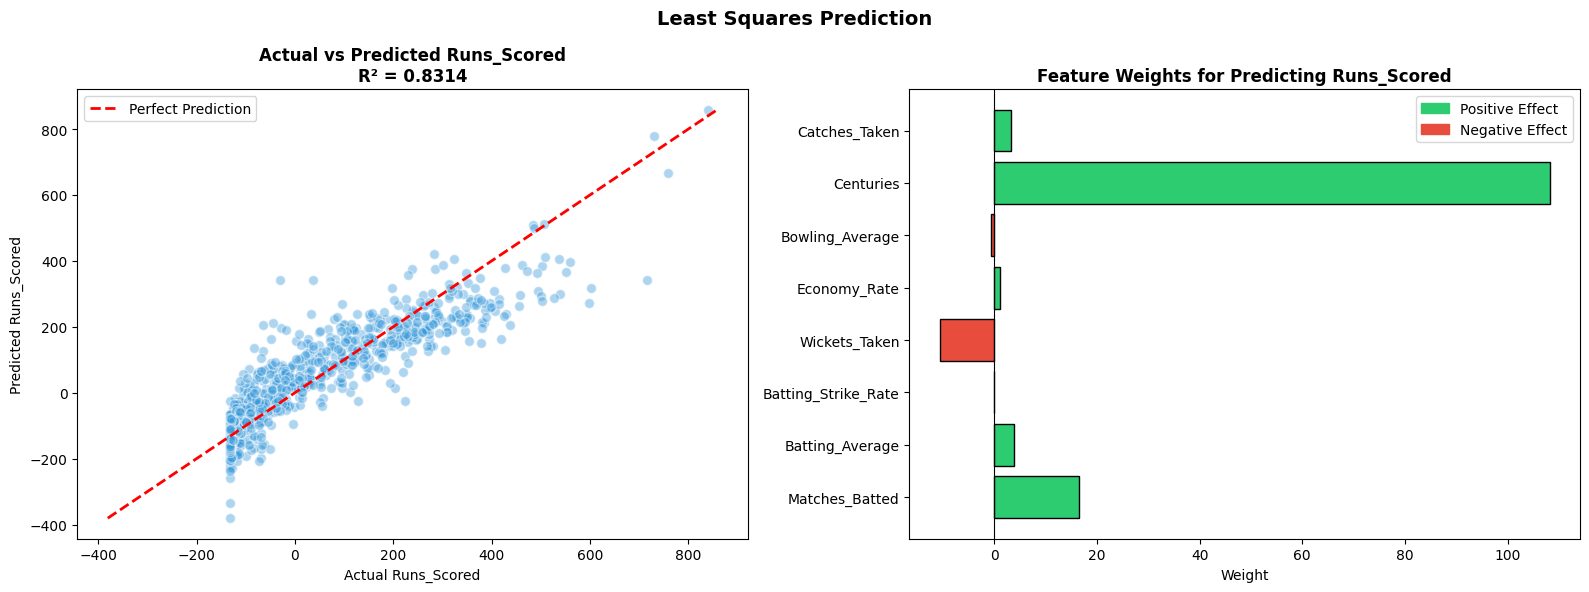

In [24]:
# --- Visualize Actual vs Predicted ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted scatter
axes[0].scatter(b, b_predicted, alpha=0.4,
                color='#3498db', edgecolor='white', s=50)
min_val = min(b.min(), b_predicted.min())
max_val = max(b.max(), b_predicted.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel(f'Actual {target_feature}')
axes[0].set_ylabel(f'Predicted {target_feature}')
axes[0].set_title(f'Actual vs Predicted {target_feature}\nR² = {r_squared:.4f}',
                  fontweight='bold')
axes[0].legend()

# Plot 2: Feature importance (weights)
colors = ['#2ecc71' if w > 0 else '#e74c3c' for w in weights]
axes[1].barh(predictor_features, weights,
             color=colors, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Weight')
axes[1].set_title(f'Feature Weights for Predicting {target_feature}',
                  fontweight='bold')

from matplotlib.patches import Patch
legend = [Patch(color='#2ecc71', label='Positive Effect'),
          Patch(color='#e74c3c', label='Negative Effect')]
axes[1].legend(handles=legend)

plt.suptitle('Least Squares Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/step7_least_squares.png', dpi=150)
plt.show()

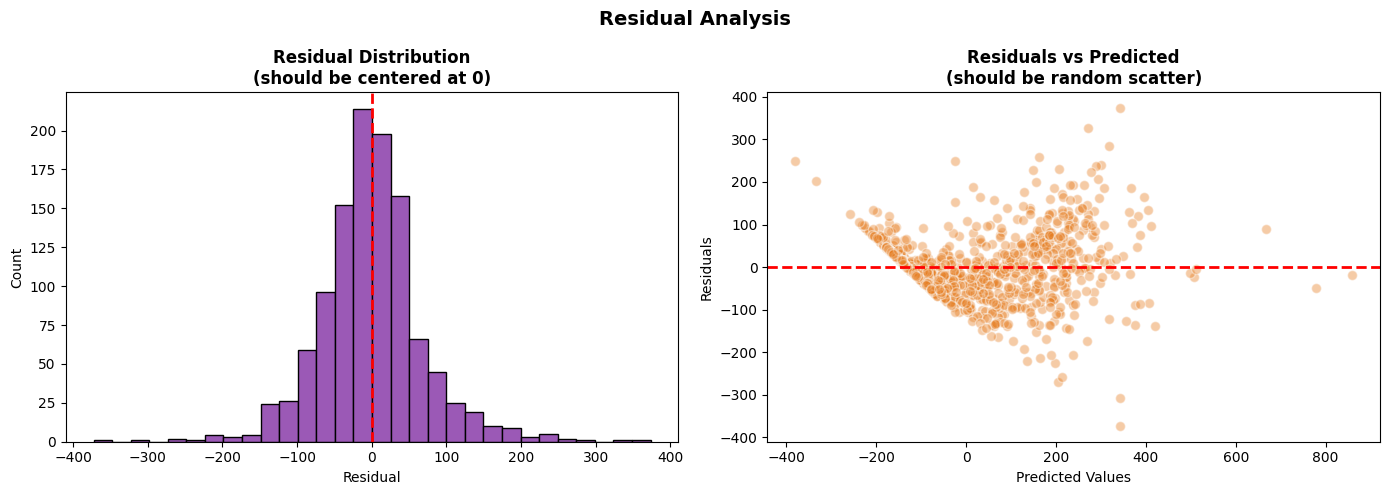

In [25]:
# --- Visualize Residuals ---
residuals_vec = b - b_predicted

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution
axes[0].hist(residuals_vec, bins=30,
             color='#9b59b6', edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual Distribution\n(should be centered at 0)',
                  fontweight='bold')

# Residuals vs Predicted
axes[1].scatter(b_predicted, residuals_vec,
                alpha=0.4, color='#e67e22',
                edgecolor='white', s=50)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted\n(should be random scatter)',
                  fontweight='bold')

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/step7_residuals.png', dpi=150)
plt.show()

In [26]:
# --- Summary ---
print("=" * 50)
print("STEP 7 SUMMARY — Least Squares Prediction")
print("=" * 50)
print(f"""
Problem Setup:
  Design Matrix X : {X_aug.shape}
  Target Vector b : {b.shape}
  Target Feature  : {target_feature}

Solution Method:
  → np.linalg.lstsq(X, b) — minimizes ||Xw - b||²
  → Verified with Normal Equations: x̂ = (XᵀX)⁻¹Xᵀb
  → Both methods produce identical results ✓

Model Performance:
  R² Score : {r_squared:.4f}
  RMSE     : {rmse:.4f}

Key Insight:
  Least squares finds the best fit even when the
  system is overdetermined (more players than features).
  This is how we predict missing player stats!
""")

# Save for Step 8
np.save('../data/b_predicted.npy', b_predicted)
np.save('../data/weights.npy', w)

print("✅ Step 7 Complete!")
print("   → Ready for Step 8: Pattern Discovery (Eigenvalues)")

STEP 7 SUMMARY — Least Squares Prediction

Problem Setup:
  Design Matrix X : (1130, 9)
  Target Vector b : (1130,)
  Target Feature  : Runs_Scored

Solution Method:
  → np.linalg.lstsq(X, b) — minimizes ||Xw - b||²
  → Verified with Normal Equations: x̂ = (XᵀX)⁻¹Xᵀb
  → Both methods produce identical results ✓

Model Performance:
  R² Score : 0.8314
  RMSE     : 70.2061

Key Insight:
  Least squares finds the best fit even when the
  system is overdetermined (more players than features).
  This is how we predict missing player stats!

✅ Step 7 Complete!
   → Ready for Step 8: Pattern Discovery (Eigenvalues)
